# Dow30 Cross-Section Evaluation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from scipy.stats import ks_2samp, gaussian_kde
from metrics.statistic import compute_corr

EXP    = "dow30"
PREFIX = f"model/{EXP}"

train_df = pd.read_parquet("data/dow30_train.parquet")
test_df  = pd.read_parquet("data/dow30_test.parquet")
TICKERS  = list(train_df.columns)

train = train_df.values.astype(np.float64)
OOS   = test_df.values.astype(np.float64)

sampled = np.load(f"{PREFIX}/samples/factor_dow30_ddpm_4096.npy").astype(np.float64)
NUM_GENERATE = len(sampled)

rng      = np.random.default_rng(0)
resample = train[rng.choice(len(train), size=NUM_GENERATE, replace=False)]
gaussian = rng.multivariate_normal(train.mean(axis=0), np.cov(train, rowvar=False),
                                   size=NUM_GENERATE)

baselines = [("Resample", resample, "#17becf"), ("Gaussian", gaussian, "#ff7f0e")]
print(f"train {train.shape}  OOS {OOS.shape}  generated {sampled.shape}")

train (53669, 30)  OOS (5950, 30)  generated (4096, 30)


## 1. Moment Comparison

Per-ticker mean / std / skewness / kurtosis of generated samples and baselines vs OOS.
Points on the diagonal = perfect match. Note the OOS period is calmer than training
(extreme minutes are concentrated in the train period), so kurtosis is not expected to match exactly.

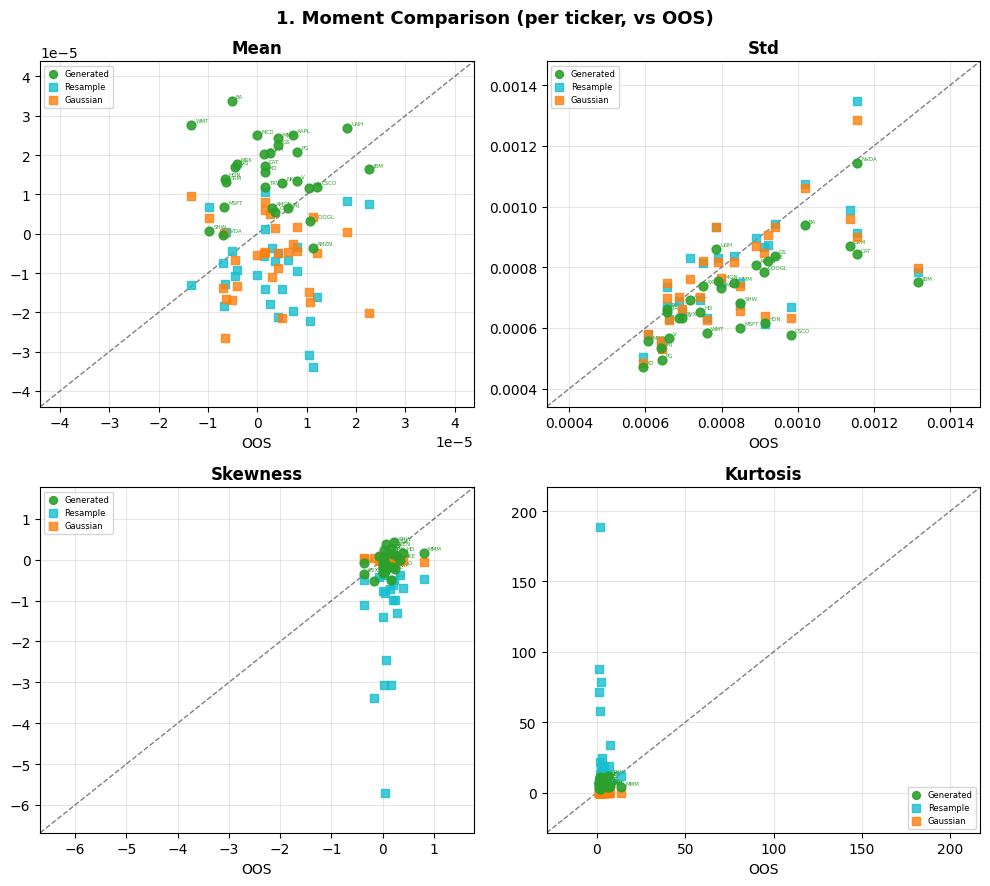

In [3]:
def compute_moments(data):
    return [np.mean(data, axis=0), np.std(data, axis=0),
            stats.skew(data, axis=0), stats.kurtosis(data, axis=0)]

moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']
m_OOS   = compute_moments(OOS)
m_gen   = compute_moments(sampled)
m_bases = [(name, compute_moments(data), c) for name, data, c in baselines]

ANNOT_FS, LEGEND_FS, PT_SIZE = 4, 6, 40

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for idx, (ax, mname) in enumerate(zip(axes.flatten(), moment_names)):
    OOS_m, gen_m = m_OOS[idx], m_gen[idx]
    all_y = [gen_m] + [bm[idx] for _, bm, _ in m_bases]

    lim = [min(OOS_m.min(), min(y.min() for y in all_y)),
           max(OOS_m.max(), max(y.max() for y in all_y))]
    pad = (lim[1] - lim[0]) * 0.15 or 0.01
    lim = [lim[0] - pad, lim[1] + pad]

    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
    ax.scatter(OOS_m, gen_m, color='#2ca02c', s=PT_SIZE, marker='o', zorder=4,
               label='Generated', alpha=0.9)
    for i, tk in enumerate(TICKERS):
        ax.annotate(tk, (OOS_m[i], gen_m[i]), fontsize=ANNOT_FS,
                    xytext=(3, 2), textcoords='offset points', color='#2ca02c')
    for (bname, bm, bc) in m_bases:
        ax.scatter(OOS_m, bm[idx], color=bc, s=PT_SIZE, marker='s', zorder=3,
                   label=bname, alpha=0.8)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('OOS')
    ax.set_title(mname, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FS, markerscale=0.9, handlelength=1.2)

fig.suptitle('1. Moment Comparison (per ticker, vs OOS)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
def fmt_mae(errs):
    return f"{np.mean(errs):.4g} ({np.std(errs):.3g})"

col_w = 22
header = f"{'Moment':<12}" + f"{'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _, _ in m_bases)
print("MAE across tickers vs OOS — mean (std):")
print(header)
print("-" * len(header))
for idx, mname in enumerate(moment_names):
    row = f"{mname:<12}{fmt_mae(np.abs(m_gen[idx] - m_OOS[idx])):<{col_w}}"
    for _, bm, _ in m_bases:
        row += f"{fmt_mae(np.abs(bm[idx] - m_OOS[idx])):<{col_w}}"
    print(row)

MAE across tickers vs OOS — mean (std):
Moment      Generated             Resample              Gaussian              
------------------------------------------------------------------------------
Mean        1.409e-05 (9.83e-06)  1.431e-05 (1.13e-05)  1.258e-05 (9.06e-06)  
Std         0.0001327 (0.000126)  0.0001076 (0.000114)  0.0001074 (0.000113)  
Skewness    0.245 (0.153)         1.122 (1.26)          0.1677 (0.176)        
Kurtosis    4.107 (2.72)          22.74 (38.2)          3.221 (2.64)          


## 2. Marginal Distributions

Per-ticker KDE of generated / baselines vs OOS (x-range clipped to the 0.2–99.8 %
quantiles for readability — minute returns have extreme outliers), followed by the
distribution of two-sample KS-test p-values across the 30 tickers.

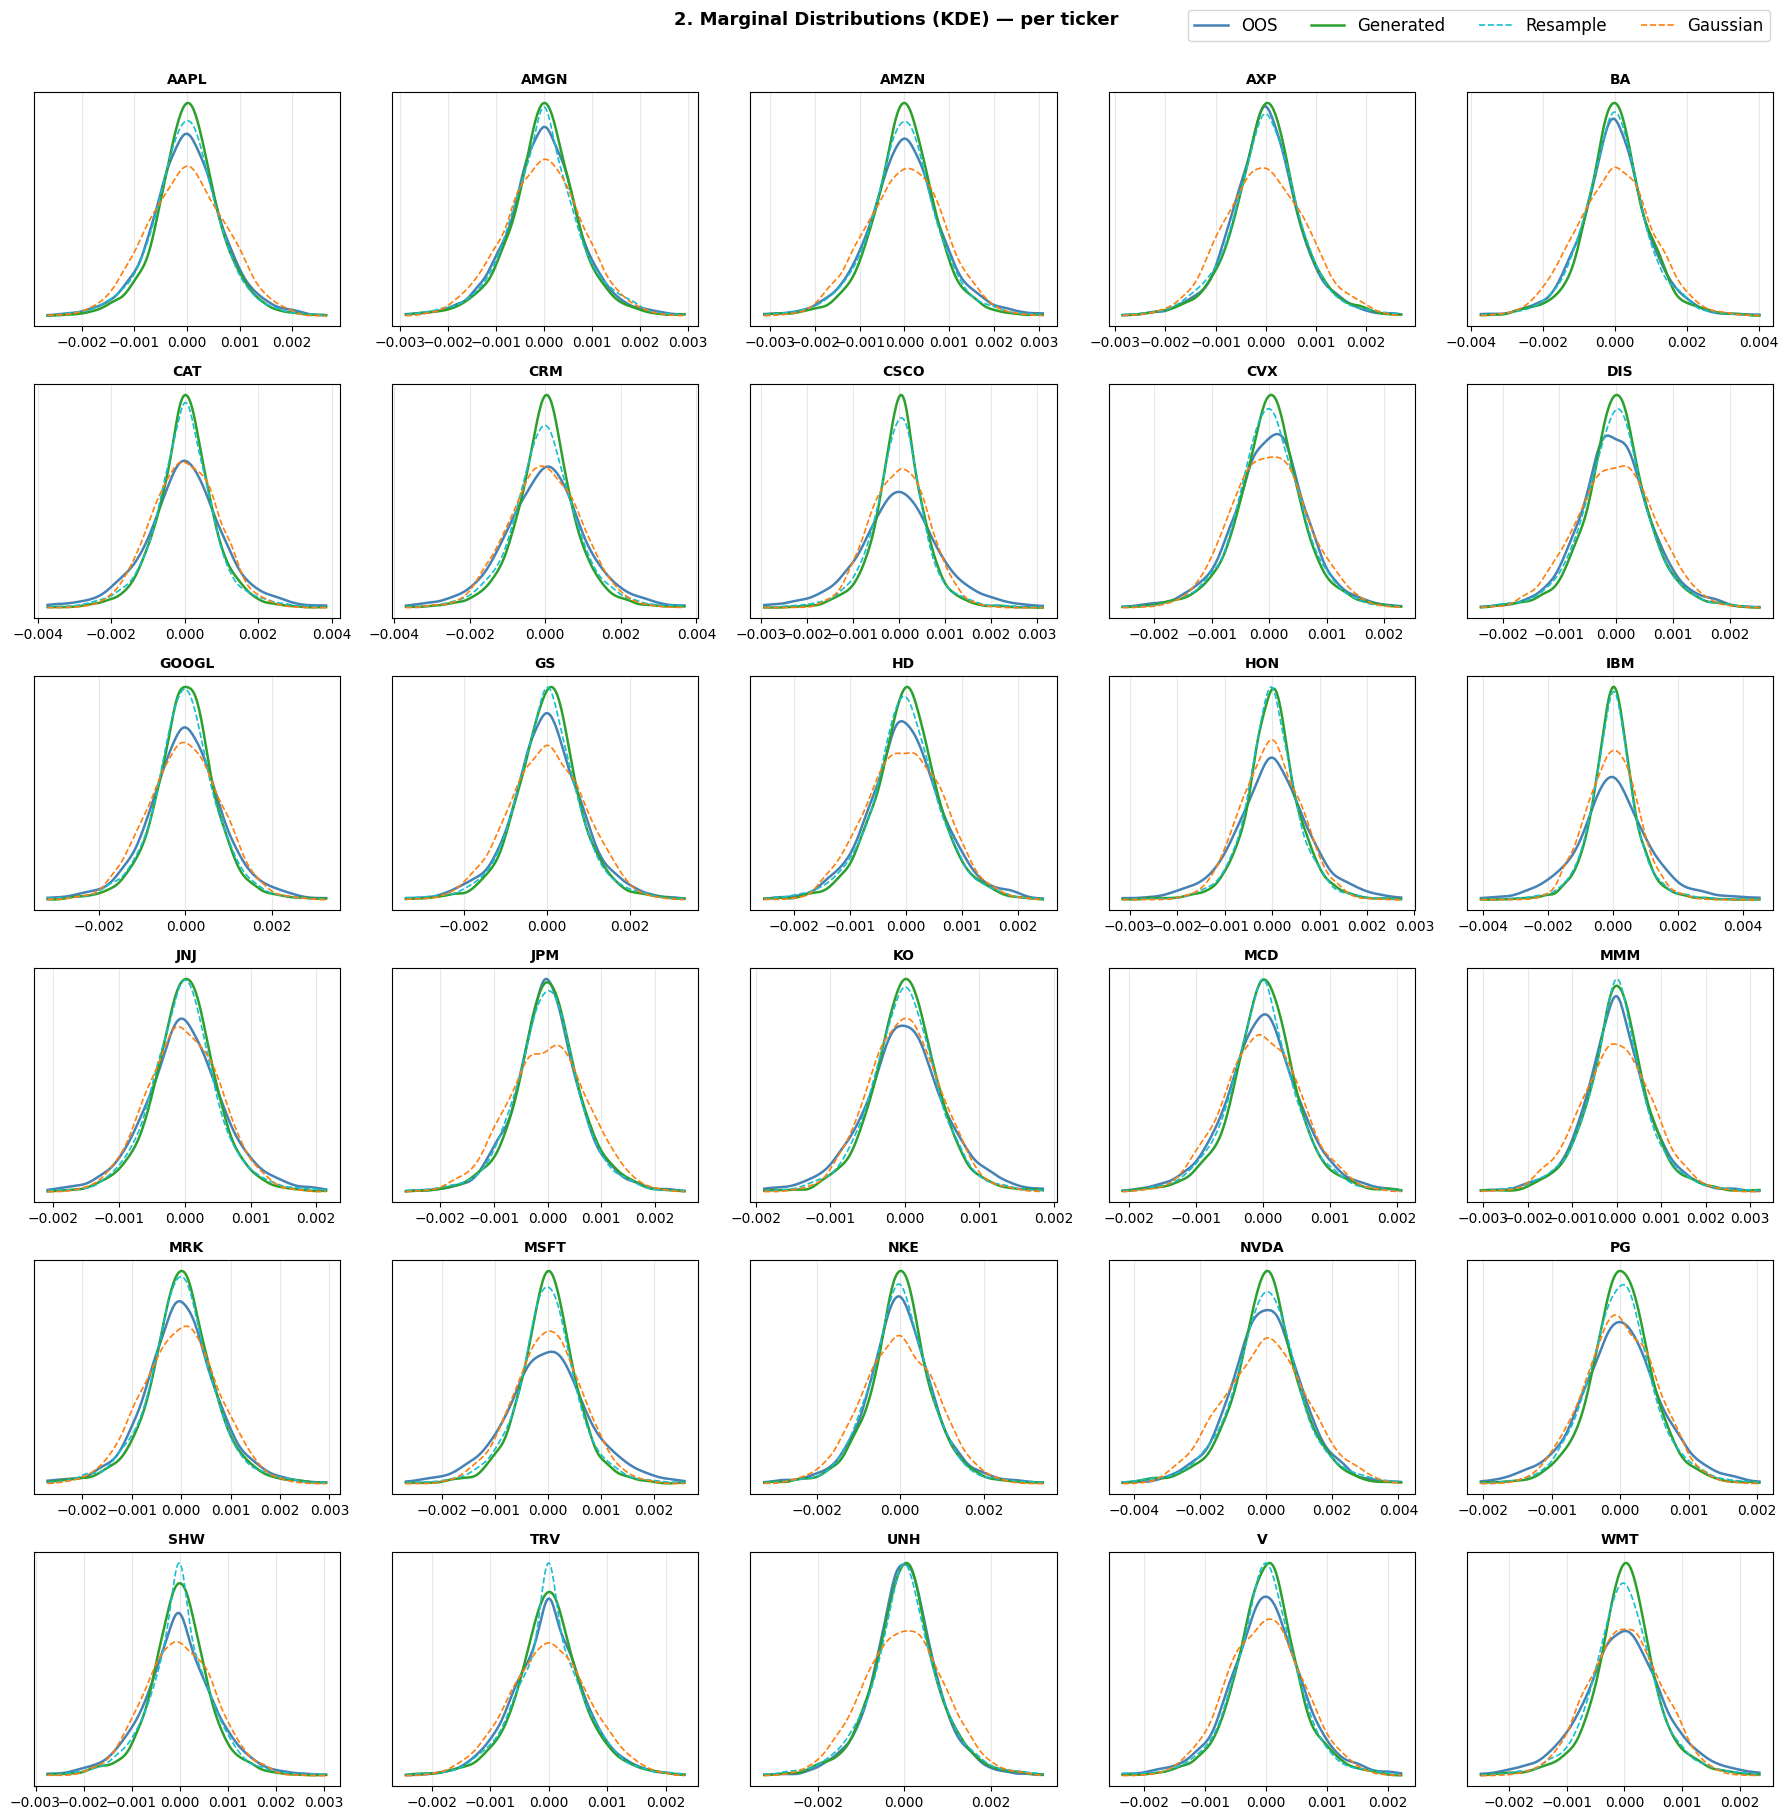

In [5]:
tyn_tickers = len(TICKERS)
fig, axes = plt.subplots(6, 5, figsize=(18, 18))

for ax, name, i in zip(axes.flatten(), TICKERS, range(n_tickers)):
    all_vals = np.concatenate([OOS[:, i], sampled[:, i]] +
                              [bdata[:, i] for _, bdata, _ in baselines])
    x_min, x_max = np.percentile(all_vals, [0.2, 99.8])
    x = np.linspace(x_min, x_max, 300)

    ax.plot(x, gaussian_kde(OOS[:, i])(x),     label='OOS',       color='steelblue', lw=1.8)
    ax.plot(x, gaussian_kde(sampled[:, i])(x), label='Generated', color='#2ca02c',   lw=1.8)
    for (bname, bdata, bc) in baselines:
        ax.plot(x, gaussian_kde(bdata[:, i])(x), label=bname, color=bc, lw=1.2, ls='--')

    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yticks([])

handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=4, fontsize=12,
           frameon=True, bbox_to_anchor=(0.99, 1.013))
fig.suptitle('2. Marginal Distributions (KDE) — per ticker', fontsize=13,
             fontweight='bold', y=1.008)
plt.tight_layout()
plt.show()

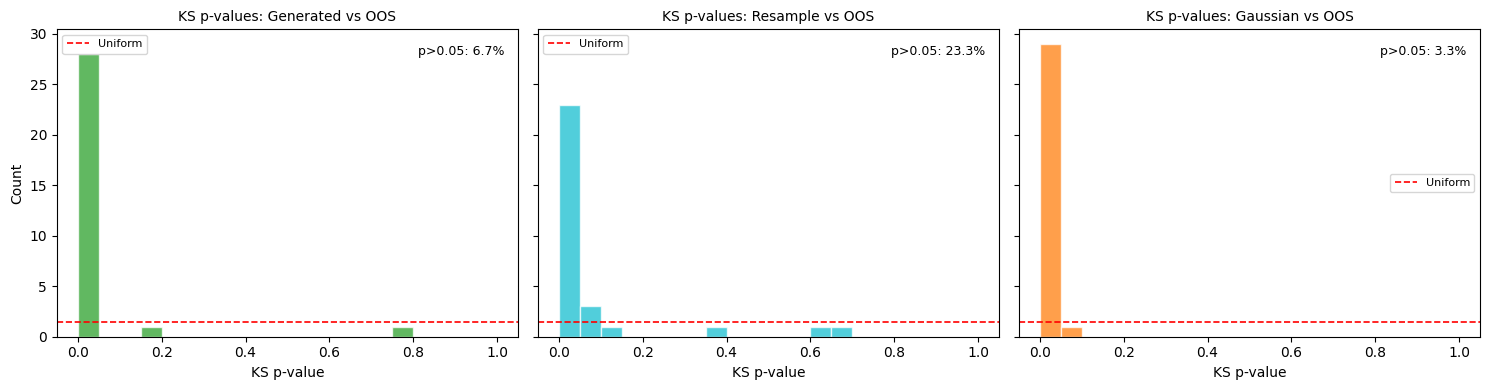

            Generated       Resample        Gaussian        
KS p>0.05   6.7%            23.3%           3.3%            


In [6]:
pvals = {name: np.array([ks_2samp(data[:, i], OOS[:, i]).pvalue
                         for i in range(n_tickers)])
         for name, data in [('Generated', sampled)] +
                            [(bn, bd) for bn, bd, _ in baselines]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
n_bins = 20
colors = {'Generated': '#2ca02c', 'Resample': '#17becf', 'Gaussian': '#ff7f0e'}

for ax, (label, pv) in zip(axes, pvals.items()):
    ax.hist(pv, bins=n_bins, range=(0, 1), color=colors[label], alpha=0.75,
            edgecolor='white')
    ax.axhline(len(pv) / n_bins, color='red', linestyle='--', lw=1.2, label='Uniform')
    ax.set_xlabel('KS p-value'); ax.set_title(f'KS p-values: {label} vs OOS', fontsize=10)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95, f"p>0.05: {(pv > 0.05).mean():.1%}", transform=ax.transAxes,
            ha='right', va='top', fontsize=9)
axes[0].set_ylabel('Count')
fig.tight_layout()
plt.show()

col_w = 16
print(f"{'':12}" + "".join(f"{k:<{col_w}}" for k in pvals))
print(f"{'KS p>0.05':<12}" + "".join(f"{(pv > 0.05).mean():<{col_w}.1%}" for pv in pvals.values()))

## 3. Tail Behavior (Q-Q Plots)

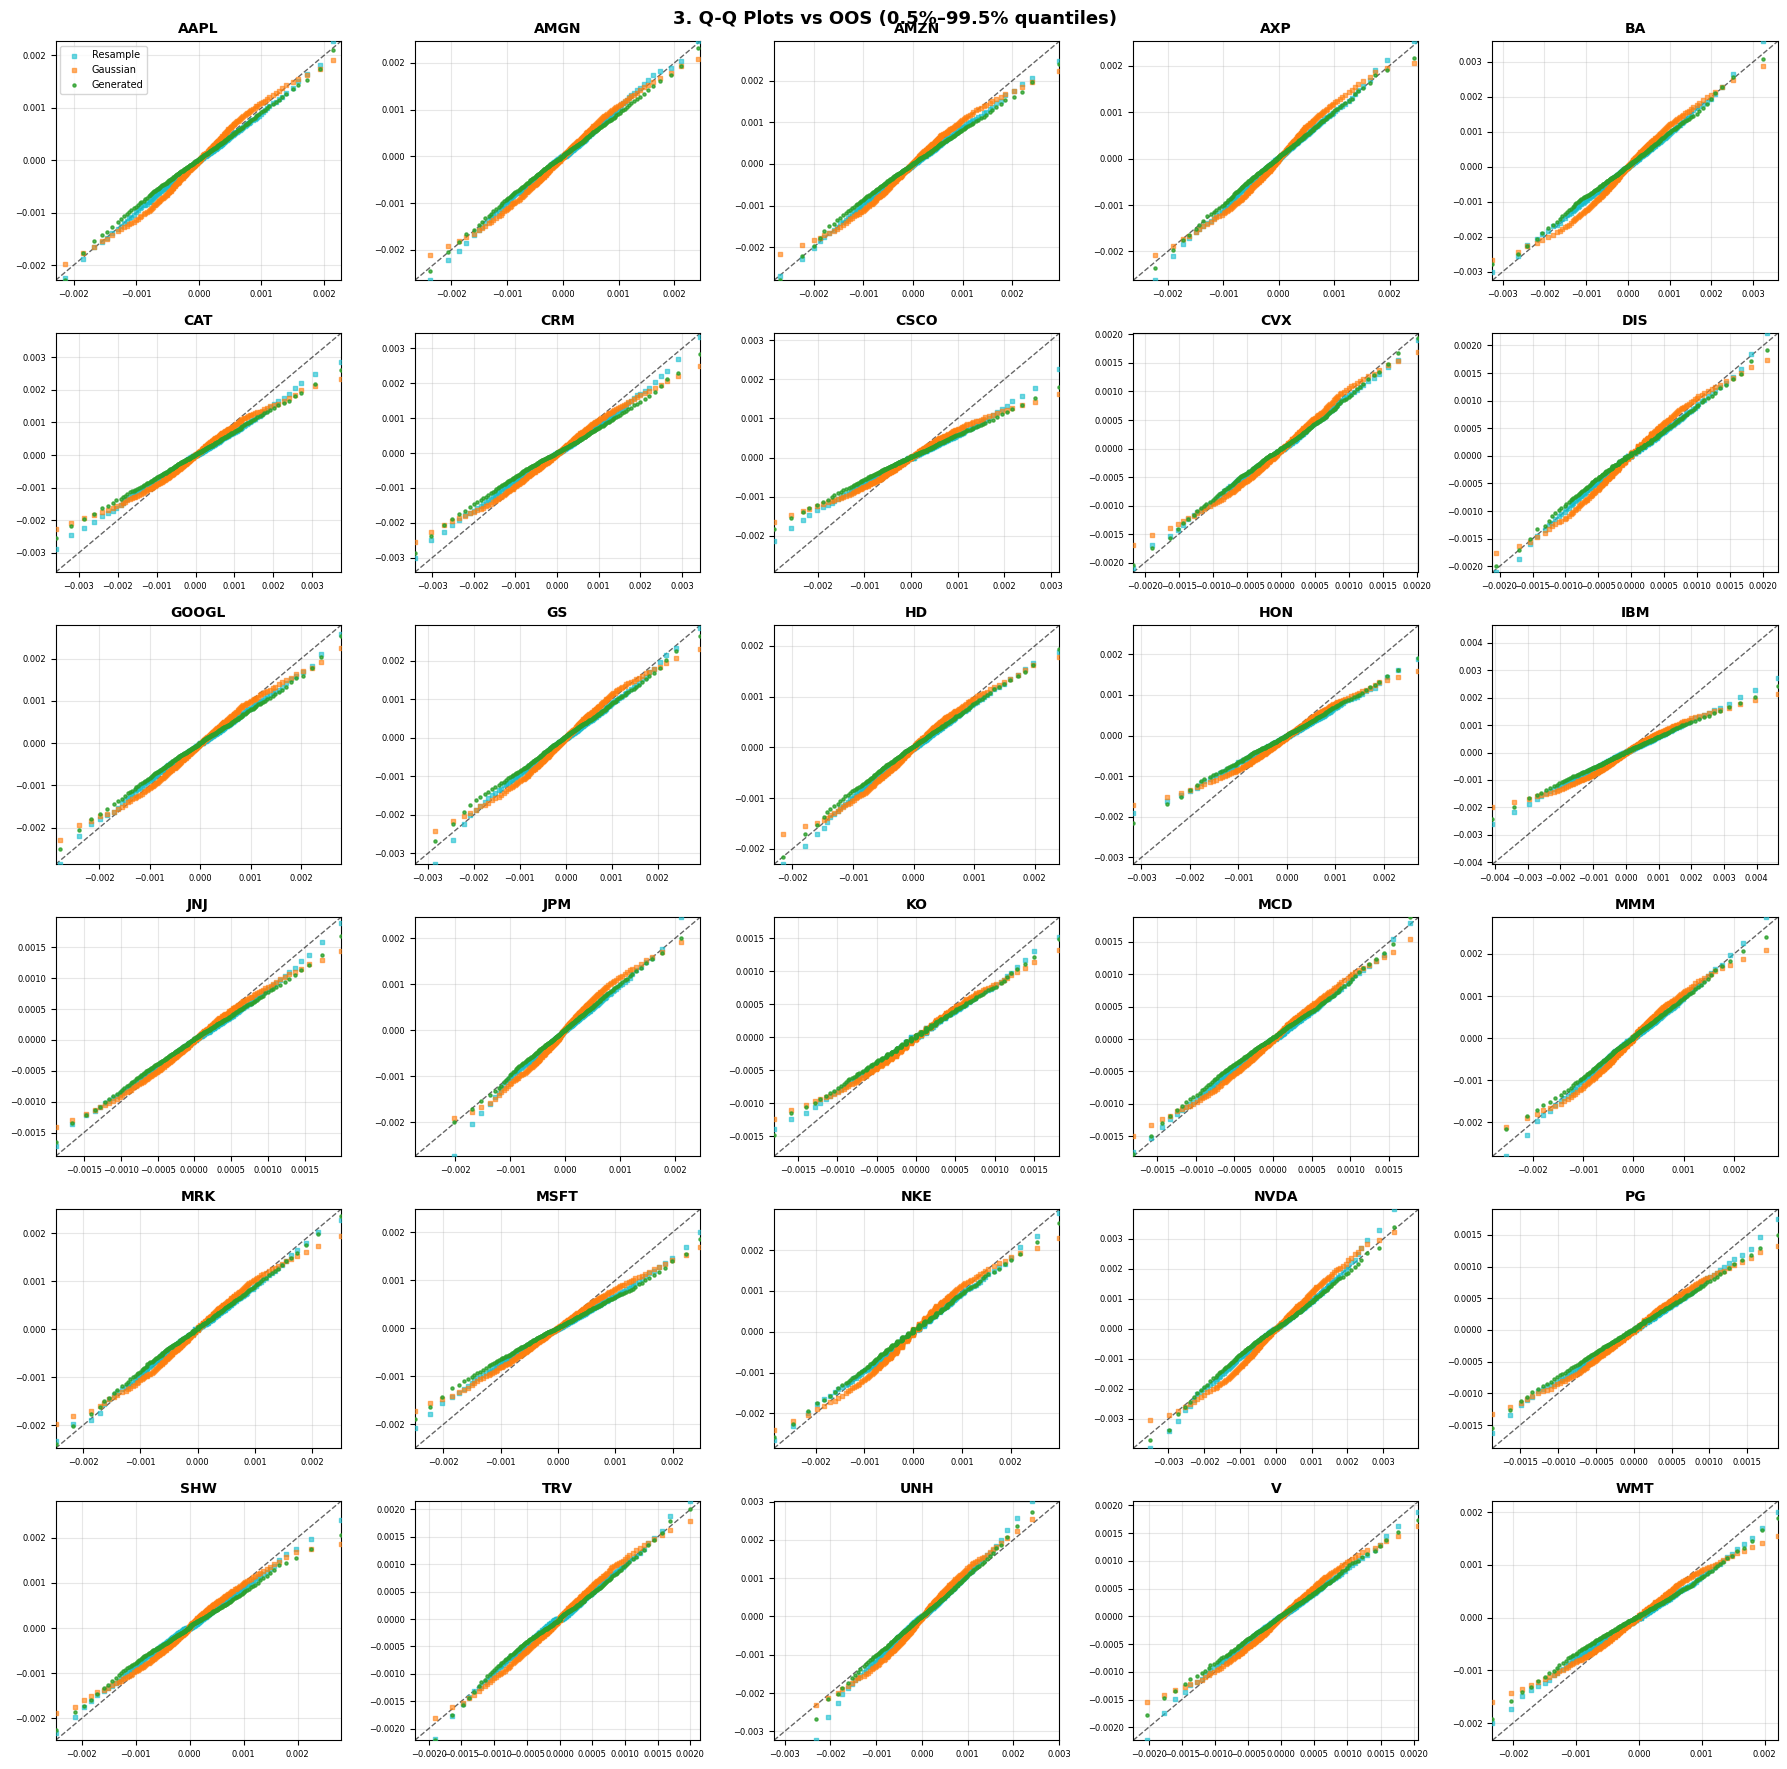

In [7]:
probs = np.linspace(0.005, 0.995, 200)

fig, axes = plt.subplots(6, 5, figsize=(18, 18))
for ax, name, i in zip(axes.flatten(), TICKERS, range(n_tickers)):
    q_OOS = np.quantile(OOS[:, i], probs)
    q_gen = np.quantile(sampled[:, i], probs)

    all_q = [q_OOS, q_gen] + [np.quantile(bdata[:, i], probs) for _, bdata, _ in baselines]
    lim = [min(q.min() for q in all_q), max(q.max() for q in all_q)]

    for (bname, bdata, bc) in baselines:
        ax.scatter(q_OOS, np.quantile(bdata[:, i], probs), s=5, color=bc,
                   zorder=3, label=bname, alpha=0.6, marker='s')
    ax.scatter(q_OOS, q_gen, s=5, color='#2ca02c', zorder=4, label='Generated', alpha=0.8)
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.6)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=6)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('3. Q-Q Plots vs OOS (0.5%–99.5% quantiles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Correlation Structure

The cross-sectional correlation matrix is the core target when training directly on the
30-stock cross-section. Heatmaps, pairwise-correlation scatter (435 pairs), and MAE /
Frobenius distances. Reference: the OOS-vs-train distance shows how much the market
itself drifted.

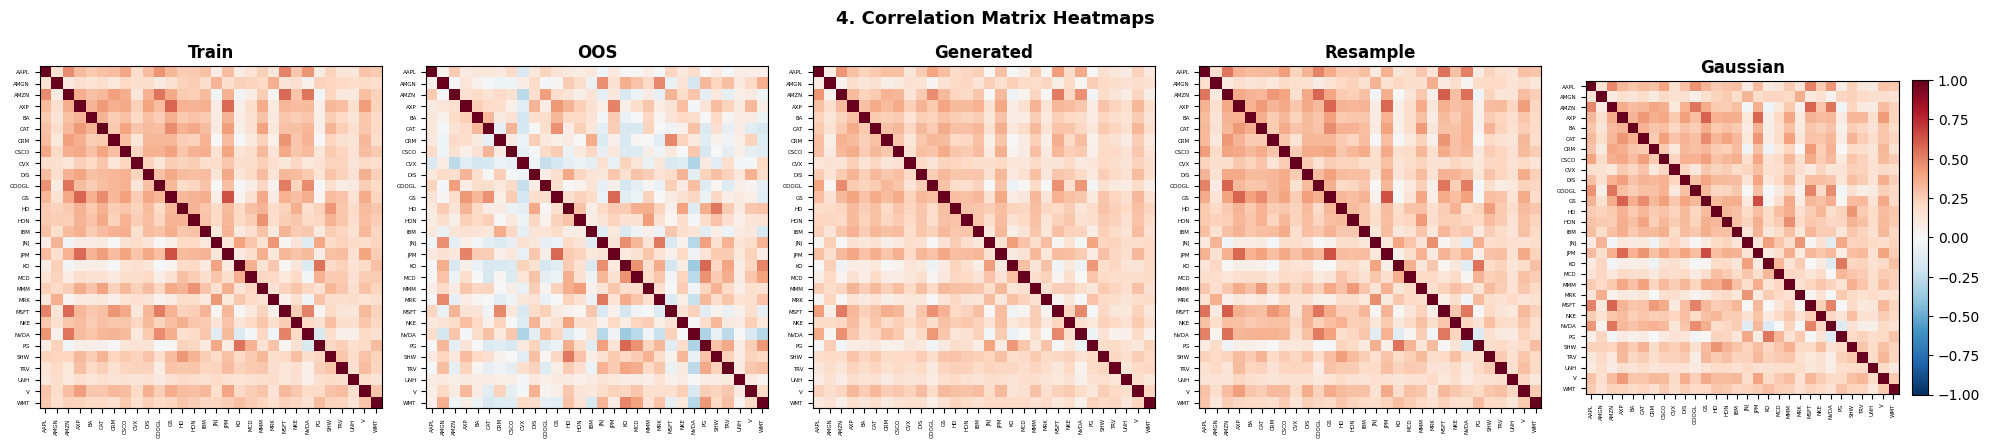

In [8]:
def corr_mat(data):
    return np.corrcoef(data, rowvar=False)

corr_train = corr_mat(train)
corr_OOS   = corr_mat(OOS)
corr_gen   = corr_mat(sampled)
corr_base  = [(bname, corr_mat(bdata), bc) for bname, bdata, bc in baselines]

all_corrs = [('Train', corr_train, 'red'), ('OOS', corr_OOS, 'steelblue'),
             ('Generated', corr_gen, '#2ca02c')] + corr_base

n = len(all_corrs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.4))
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for ax, (name, corr, _) in zip(axes, all_corrs):
    im = ax.imshow(corr, cmap='RdBu_r', norm=norm)
    ax.set_xticks(range(n_tickers)); ax.set_yticks(range(n_tickers))
    ax.set_xticklabels(TICKERS, rotation=90, fontsize=4)
    ax.set_yticklabels(TICKERS, fontsize=4)
    ax.set_title(name, fontweight='bold')

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
fig.suptitle('4. Correlation Matrix Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

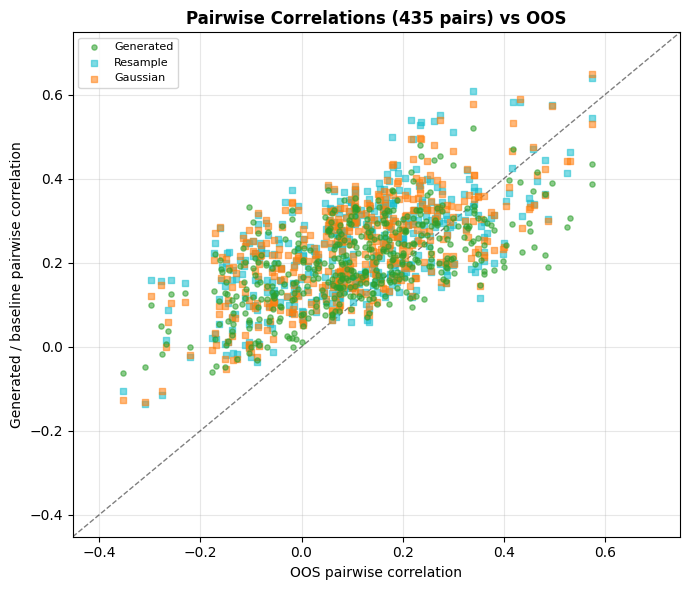

Correlation-matrix distance vs OOS        MAE (offdiag)   Frobenius
--------------------------------------------------------------------
  Generated                                 0.1285          4.668
  Resample                                  0.1494          5.333
  Gaussian                                  0.1465          5.203
  Train                                     0.1436          5.124


In [9]:
triu = np.triu(np.ones((n_tickers, n_tickers), dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7, 6))
vecs = [('Generated', corr_gen[triu], '#2ca02c', 'o')] + \
       [(bname, bc_corr[triu], bc, 's') for bname, bc_corr, bc in corr_base]
lim = [min(corr_OOS[triu].min(), min(v.min() for _, v, _, _ in vecs)),
       max(corr_OOS[triu].max(), max(v.max() for _, v, _, _ in vecs))]
pad = (lim[1] - lim[0]) * 0.1
lim = [lim[0] - pad, lim[1] + pad]

ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
for name, v, c, m in vecs:
    ax.scatter(corr_OOS[triu], v, color=c, s=14, marker=m, alpha=0.55, label=name,
               zorder=4 if name == 'Generated' else 3)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('OOS pairwise correlation')
ax.set_ylabel('Generated / baseline pairwise correlation')
ax.set_title('Pairwise Correlations (435 pairs) vs OOS', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fro = lambda A, B: np.linalg.norm(A - B, 'fro')
print("Correlation-matrix distance vs OOS        MAE (offdiag)   Frobenius")
print("-" * 68)
for name, corr, _ in [('Generated', corr_gen, None)] + \
                     [(bn, bc_corr, None) for bn, bc_corr, _ in corr_base] + \
                     [('Train', corr_train, None)]:
    data = {'Generated': sampled, 'Resample': resample,
            'Gaussian': gaussian, 'Train': train}[name]
    print(f"  {name:<38}    {compute_corr(data, OOS):<14.4f}  {fro(corr, corr_OOS):.3f}")